In [29]:
import os
import re
import pickle
from tqdm import tqdm
from typing import Iterator, Tuple

import cv2
import pillow_heif
from PIL import Image

import numpy as np
import pandas as pd

import tokenizers
import transformers
from tokenizers import trainers, processors, pre_tokenizers

import torch
import torchvision
import torchsummary
from torch.nn import utils
from torch import nn, optim, onnx, distributions
from torch.utils import data
from torchvision import io, transforms
from torchvision.transforms import functional

#adding ability to open heic images
pillow_heif.register_heif_opener()

In [2]:
#global parameters
D_MODEL = 512
N_HEADS = 8
NUM_LAYERS = 9

In [3]:
#checking cuda
torch.cuda.is_available()

True

In [214]:
model = torchvision.models.resnet18(weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1, progress = True)
#display forward propogation of initial resnet
torchsummary.summary(model, (3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

In [216]:
resnet_without_last_two = nn.Sequential(*list(model.children())[:-2])
#display forward propogation of resnet without average pooliing and linear head
torchsummary.summary(resnet_without_last_two, (3,224,224))

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

Layer (type:depth-idx)                   Output Shape              Param #
├─Conv2d: 1-1                            [-1, 64, 112, 112]        9,408
├─BatchNorm2d: 1-2                       [-1, 64, 112, 112]        128
├─ReLU: 1-3                              [-1, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [-1, 64, 56, 56]          --
├─Sequential: 1-5                        [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-1                   [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-1                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-2             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-3                    [-1, 64, 56, 56]          --
|    |    └─Conv2d: 3-4                  [-1, 64, 56, 56]          36,864
|    |    └─BatchNorm2d: 3-5             [-1, 64, 56, 56]          128
|    |    └─ReLU: 3-6                    [-1, 64, 56, 56]          --
|    └─BasicBlock: 2-2                   [-1, 64, 56, 56]          --
|

In [229]:
for name, parameter in resnet_without_last_two.named_parameters():
    if name.split('.')[0] != '7':
        parameter.requires_grad = False

In [230]:
#see if we can freeze weights of all functions
for name, parameter in resnet_without_last_two.named_parameters():
    print(name.split('.')[0], parameter.requires_grad)

0 False
1 False
1 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
4 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
5 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
6 False
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True
7 True


In [226]:
last_child = list(resnet_without_last_two.children())[-1]
last_child

Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(256, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (downsample): Sequential(
      (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (1): BasicBlock(
    (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(512, eps=1

In [5]:
def resnet_trans(pil_image):
    """
    Parameters
    ----------
    pil_image: image opend with pillow library 
    
    returns
    ----------
    Tensor image transformed for ResNet; with dtype float32
    """
    #apply necessary transformations for ResNet
    data_transforms = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize((224,224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    return data_transforms(pil_image)

In [6]:
def get_tokenizer_object(words_iterable):
    """
    Parameters
    ----------
    Iterable of words

    returns
    -------
    a tokenizer object that implements all the necessary 
    special tokens additions

    Description
    ------------
    Takes in an iterable of words and returns a HF tokenizer object over them
    that appends all the necessary special tokens

    Note
    -----
    The tokenizer would expect the words that have single spaces between the letters
    example: 'cat' --> 'c a t'
    """
    #get maximum length of words
    max_length = 0
    for word in words_iterable:
        max_length = max(max_length,len(word))
    #adding 2 for sos and eos tokens 
    max_length += 2
    #creating words with spaces between letters
    main_iterable_of_words = [' '.join([letter for letter in word]) for word in words_iterable]
    #specifiing tokenizer parameters
    tokenizer_obj = tokenizers.Tokenizer(model=tokenizers.models.WordLevel(unk_token='<unk>'))
    tokenizer_obj.pre_tokenizer = pre_tokenizers.Whitespace()
    tokenizer_obj.post_processor = processors.TemplateProcessing(single="<sos> $A <eos>", special_tokens=[('<sos>',2), ('<eos>',3)])
    #enabling padding with maximun length
    tokenizer_obj.enable_padding(direction='right', pad_id = 0, pad_token='<pad>', length=max_length)
    #training tokenizer object
    tokenizer_trainer = trainers.WordLevelTrainer(vocab_size=100, special_tokens=['<pad>','<unk>','<sos>','<eos>'])
    tokenizer_obj.train_from_iterator(iterator=main_iterable_of_words, trainer=tokenizer_trainer)
    #transformers tokenizer
    transformers_tokenizer = transformers.PreTrainedTokenizerFast(tokenizer_object = tokenizer_obj)
    return transformers_tokenizer 

In [38]:
#here I also have to add a class of picture distribution for further stratification
def get_dataset(path_to_folder = '/home/luchian/all_data/datasets/text_rec_dataset'):
    """
    Parameters
    ----------
    An absolute path to folder with dataset
    
    returns
    --------
    a dataframe that has the column names [image_path, target]
    with corresponding data

    Description
    ------------
    Takes in an absolute path to a folder that contains data in the form
    folder_with_target_name[images]
    i.e. each target has a folder of its name with images in it belonging to that target
    """
    #create a dataframe
    main_frame = pd.DataFrame(columns=['ImagePath','Target'])
    #get target folders
    list_of_target_folders = os.listdir(path_to_folder)
    #for each target folder get the images with that target
    for target_name in list_of_target_folders:
        images = os.listdir(path_to_folder+'/'+target_name)
        pd_frame = pd.DataFrame({'ImagePath':[path_to_folder+'/'+target_name+'/'+image_path for image_path in images], 'Target':[target_name for _ in range(len(images))]})
        main_frame = pd.concat([main_frame, pd_frame], ignore_index=True) #ignore index to make shure we have regular indexing order 
    return main_frame

In [8]:
def pos_embeds(embedding_matrix, dev = 'cpu'):
    """
    Parameters
    ----------
    embedding matrix: torch.Tensor of shape (batch_size, seq_len, embedding_dim)

    returns
    -------
    embedding matrix + positional encoding
    same embedding matrix with added positional embeddings
    """
    _, seq_len, embed_dim = tuple(embedding_matrix.shape)
    #creating positional embedding matrix
    pos_embeds = [] 
    for pos in range(seq_len):
        index_matrix = torch.arange(0, embed_dim).to(dtype = torch.float32, device=dev).reshape(1,-1)
        #to even apply sin function
        index_matrix[index_matrix%2 == 0] = torch.sin(pos/10_000**index_matrix[index_matrix%2 == 0]/embed_dim)
        #to odd apply cos function but also with even indecies (that's why we extract 1)
        index_matrix[index_matrix%2 == 1] = torch.cos(pos/10_000**((index_matrix[index_matrix%2 == 1]-1)/embed_dim))
        pos_embeds.append(index_matrix)
    #perform concatenation of resulting rows for each position
    pos_embeds = torch.cat(pos_embeds)
    #for each batch we add positional encodings
    embedding_matrix = embedding_matrix + pos_embeds
    return embedding_matrix

In [9]:
def make_spaces(word):
    """Makes spaces between the letter of a given word"""
    return ' '.join(list(word))

In [10]:
class TextRecDataset(data.Dataset):
    """Implements dataset for Text Recognition"""
    def __init__(self,dataset: pd.DataFrame, tokenizer: transformers.PreTrainedTokenizerFast, word_processor = make_spaces, picture_processor = resnet_trans):
        self.dataset = dataset
        self.tokenizer = tokenizer
        #processors for words and pictures
        self.word_processor = word_processor
        self.picture_processor = picture_processor

    def __len__(self):
        return len(self.dataset)
    
    def __getitem__(self,indx):
        #getting image path and target name
        data_indx_row = self.dataset.iloc[indx,:]
        image_path = data_indx_row['ImagePath']
        target_name = data_indx_row['Target']
        #applying transformations and converting to necessary formats (Tensors)
        tensor_image = self.picture_processor(Image.open(image_path))
        #target names to tensors with a given tokenizer
        target_ids = torch.tensor(self.tokenizer(self.word_processor(target_name)).input_ids, dtype = torch.long)
        return tensor_image, target_ids[:-1], target_ids[1:]

In [35]:
#Enocder-Decoder model for TextRecognition 
class TRModel(nn.Module):
    def __init__(self, vocabulary_size, d_model = D_MODEL, nhead = N_HEADS, num_layers = NUM_LAYERS, padding_indx = 0, device = 'cpu'):
        super().__init__()
        self.device = device
        #Encoder
        #load ResNet with last two functions removed
        self.encoder = nn.Sequential(*list(torchvision.models.resnet18(weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1, progress = False).children())[:-2])

        #linear head that project to embedding dimension
        self.linear_encoder_head = nn.Linear(512,d_model)

        #Decoder
        #embedding layer
        self.embed_layer = nn.Embedding(num_embeddings=vocabulary_size, embedding_dim=d_model, padding_idx=padding_indx)
        self.decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead)
        self.decoder = nn.TransformerDecoder(self.decoder_layer, num_layers=num_layers)

        #linear head over vocabulary
        self.linear_head = nn.Linear(d_model,vocabulary_size)

    def forward(self, x_pic_tensor, x_letter_ids):
        """
        parameters
        ----------
        x_pic: tensor of shape batch_size X channels X H x W
        x_text: tensor of shape seq_len X batch_size X d_model (embed_dim)
        """
        encoder_forward = self.encoder(x_pic_tensor)
        encoder_forward = encoder_forward.reshape(encoder_forward.shape[0], encoder_forward.shape[1], -1)
        #reshape to shape (batch_size, spatial_sequence_len, num_channels)
        encoder_forward = encoder_forward.transpose(1,2)
        #adding positional embeddings
        with torch.no_grad():
            encoder_forward = pos_embeds(encoder_forward, dev = self.device)
        #projecting number of channels to d_model shape
        encoder_forward = self.linear_encoder_head(encoder_forward)
        #reshaping to shape (seq_len, batch_size, embed_dim (d_model))
        encoder_forward = encoder_forward.transpose(0,1)
        
        #getting vector embeddings
        letter_embeds = self.embed_layer(x_letter_ids) 
        #add positional embeddings and reshaping to seq_len first
        with torch.no_grad():
            letter_embeds = pos_embeds(letter_embeds, dev = self.device).transpose(0,1)
        #going through decoder
        decoder_forward = self.decoder(letter_embeds, memory = encoder_forward)
        clf_head = self.linear_head(decoder_forward)
        return clf_head

In [37]:
#here I will create metrics for my model
def metric1(some_string):
    return 0

def metric2(some_string):
    return 0

In [998]:
sample = next(iter(loader))
print(sample[0].shape)
print(sample[1].shape)

torch.Size([2, 3, 224, 224])
torch.Size([2, 4])


In [14]:
model = TRModel(vocabulary_size=TorchDataset.tokenizer._tokenizer.get_vocab_size())

In [1000]:
value = model(x_pic_tensor = sample[0], x_letter_ids = sample[1])
value.shape

torch.Size([4, 2, 10])

In [20]:
def train_model(model,train_loader,epoch,main_optim,scheduler,main_loss,print_every = 1,dev = 'cpu'):
    """
    Given training parameters trains the model
    """
    #Handling KeyBoardInterrupt exception error
    try:
        train_losses = []
        #Going through epochs
        for ep in range(epoch):
            model.train()
            #we are going to save the mean of losses
            epoch_losses = []
            for X,y,z in tqdm(train_loader, desc=f'Going through the loader on epoch #{ep+1}'):
                #preparing for forward propogation
                X,y,z = X.to(device = dev), y.to(device = dev), z.to(device = dev)
                main_optim.zero_grad()
                #reshape prediction and true values to go through loss
                y_pred = model(x_pic_tensor = X, x_letter_ids = y).transpose(0,1).transpose(1,2)
                the_loss = main_loss(y_pred,z)
                #backprop and clipping
                the_loss.backward()
                main_optim.step()
                #scheduler step
                if scheduler != None:
                    scheduler.step()
                #keep track of losses
                epoch_losses.append(the_loss.item())
            #for each epoch we append the mean loss over that epoch
            train_losses.append(round(np.array(epoch_losses).mean().item(),5))
            if ep%print_every == 0:
                print(f'Epoch #{ep+1} | Train loss: {train_losses[-1]}',end = '\n\n')
        return train_losses
    except KeyboardInterrupt:
        return train_losses

In [13]:
pd_dataset = get_dataset()
TorchDataset = TextRecDataset(pd_dataset, get_tokenizer_object(pd_dataset['Target']), picture_processor = resnet_trans)
TorchDataset

In [22]:
data_sample = TorchDataset[0]

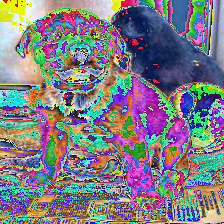

In [23]:
transforms.ToPILImage()(data_sample[0])

In [36]:
model = TRModel(vocabulary_size=TorchDataset.tokenizer._tokenizer.get_vocab_size(),device='cuda').to(device = 'cuda')

In [216]:
#train
epoch = 250
batch_size = 2
lr = 0.001
loader = data.DataLoader(dataset = TorchDataset,shuffle = True,batch_size = batch_size)
optimizer = optim.SGD(params=model.parameters(), lr=lr,momentum = 0.55)
criterion = nn.CrossEntropyLoss(reduction = 'mean', ignore_index=0)

In [217]:
results = train_model(model = model,
                      train_loader = loader,
                      epoch = epoch,
                      main_optim = optimizer,
                      scheduler=None,
                      main_loss = criterion,
                      print_every = 50,
                      dev = 'cuda')

Going through the loader on epoch #1: 100%|██████████| 1/1 [00:00<00:00, 18.56it/s]


Epoch #1 | Train loss: 0.00417



Going through the loader on epoch #51: 100%|██████████| 1/1 [00:00<00:00, 18.25it/s]


Epoch #51 | Train loss: 0.00407



Going through the loader on epoch #101: 100%|██████████| 1/1 [00:00<00:00, 18.13it/s]


...

Going through the loader on epoch #151: 100%|██████████| 1/1 [00:00<00:00, 17.94it/s]


Epoch #151 | Train loss: 0.00378



Going through the loader on epoch #201: 100%|██████████| 1/1 [00:00<00:00, 18.24it/s]


Epoch #201 | Train loss: 0.00371



Going through the loader on epoch #250: 100%|██████████| 1/1 [00:00<00:00, 17.91it/s]


In [ ]:
#torch save model weights
# torch.save(model.state_dict(),f = '/home/luchian/all_data/ML_models_weights/TexRec_Overfit2_v1_weights.pth')

In [37]:
#torch load state dits of model
model.load_state_dict(torch.load(f='/home/luchian/all_data/ML_models_weights/TexRec_Overfit2_v1_weights.pth'))

<All keys matched successfully>

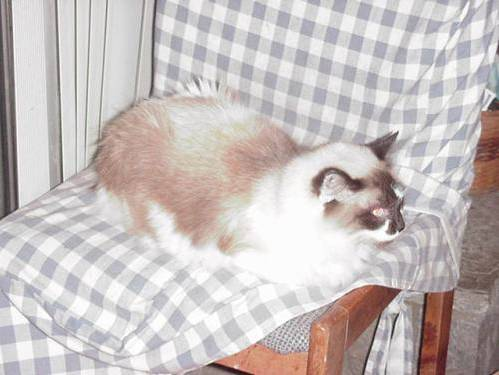

In [22]:
pil_cat = Image.open('/home/luchian/all_data/datasets/text_rec_dataset/cat/cat.jpg')
pil_cat

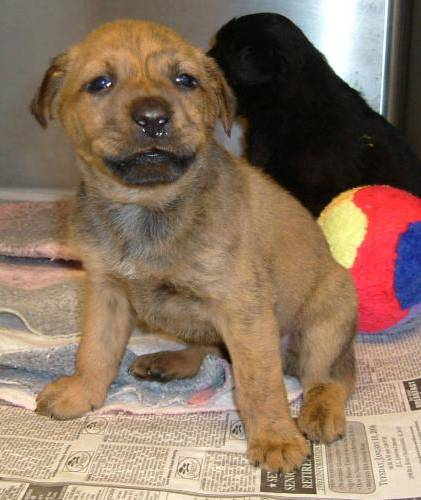

In [17]:
pil_dog = Image.open('/home/luchian/all_data/datasets/text_rec_dataset/dog/dog.jpg')
pil_dog

In [18]:
main_tokenizer = TorchDataset.tokenizer

In [27]:
def model_inference(pillow_picture, model, tokenizer, word_transform = make_spaces, picture_transform = resnet_trans, device = 'cuda', limit = 100):
    """
    Description
    -----------
    Given an image returns generated text
    """
    #change model state to evaluation
    model.eval()
    #transform picture for forward pass
    tensor_picture = picture_transform(pillow_picture).unsqueeze(dim = 0).to(device = device)
    #creating starting sequence
    sequence = ''
    #while last token does not equal to eos or limit achieved keep generating
    iter_count = 0
    while True and iter_count < limit:
        #update count
        iter_count += 1
        sequence_tensor = torch.tensor(tokenizer(word_transform(sequence)).input_ids[:-1]).reshape(1,-1).to(device = device)
        y_pred = model(x_pic_tensor = tensor_picture, x_letter_ids = sequence_tensor).squeeze(dim = 1)[-1].softmax(dim = 0) #choose the last token probabilities
        #make distribution over vocabulary tokens
        next_sampled_token = y_pred.argmax(dim = 0).detach().cpu().item()
        #if we reached the last token we break (else continute)
        if next_sampled_token == tokenizer._tokenizer.get_vocab()['<eos>']:
            break
        else:
            #add new token
            sequence += tokenizer._tokenizer.id_to_token(next_sampled_token)
    return sequence

In [31]:
prediction = model_inference(pillow_picture=pil_dog, model=model, tokenizer=main_tokenizer)
prediction

'dog'

In [ ]:
#saving tokenizer artifact for future inference
with open('/home/luchian/prog/self_prog/Projects/TextRecognition/backend/model_tokenizer.pkl','wb') as pickle_file:
    pickle.dump(TorchDataset.tokenizer,  pickle_file)